<a href="https://colab.research.google.com/github/fizzahahmed/hangman-game-cpp/blob/main/BikeRentalDemandPrediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

bike_url = "https://raw.githubusercontent.com/byui-cse/cse450-course/master/data/bikes.csv"
df = pd.read_csv(bike_url)

print("--- DATASET PREVIEW ---")
display(df.head())

print("\n--- DATASET SHAPE ---")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

print("\n--- DATA TYPES & INFO ---")
print(df.info())

print("\n--- STATISTICAL SUMMARY ---")
display(df.describe())

--- DATASET PREVIEW ---


,dteday,hr,casual,registered,temp_c,feels_like_c,hum,windspeed,weathersit,season,holiday,workingday
0,1/1/2011,0.0,3,13,3.0,3.0,0.7957,0.8,1,1,0,0
1,1/1/2011,1.0,8,30,1.7,1.7,0.8272,0.8,1,1,0,0
2,1/1/2011,2.0,5,26,1.9,1.9,0.8157,1.1,1,1,0,0
3,1/1/2011,3.0,3,9,2.5,2.5,0.7831,0.8,1,1,0,0
4,1/1/2011,4.0,0,1,2.0,2.0,0.8075,1.1,1,1,0,0



--- DATASET SHAPE ---
Rows: 112475, Columns: 12

--- DATA TYPES & INFO ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112475 entries, 0 to 112474
Data columns (total 12 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   dteday        112475 non-null  object 
 1   hr            112475 non-null  float64
 2   casual        112475 non-null  int64  
 3   registered    112475 non-null  int64  
 4   temp_c        112475 non-null  float64
 5   feels_like_c  112475 non-null  float64
 6   hum           112475 non-null  float64
 7   windspeed     112475 non-null  float64
 8   weathersit    112475 non-null  int64  
 9   season        112475 non-null  int64  
 10  holiday       112475 non-null  int64  
 11  workingday    112475 non-null  int64  
dtypes: float64(5), int64(6), object(1)
memory usage: 10.3+ MB
None

--- STATISTICAL SUMMARY ---


,hr,casual,registered,temp_c,feels_like_c,hum,windspeed,weathersit,season,holiday,workingday
count,112475.000000,112475.000000,112475.000000,112475.000000,112475.000000,112475.000000,112475.000000,112475.000000,112475.000000,112475.000000,112475.000000
mean,11.501098,90.434612,249.193625,15.376487,14.659325,0.636624,13.100614,1.405441,2.495799,0.030300,0.684312
std,6.921864,128.655621,258.267544,9.749467,11.428324,0.190328,7.857600,0.683450,1.101152,0.171412,0.464791
min,0.000000,0.000000,0.000000,-14.700000,-24.000000,0.088900,0.000000,1.000000,1.000000,0.000000,0.000000
25%,6.000000,7.000000,48.000000,7.600000,5.400000,0.484100,7.700000,1.000000,2.000000,0.000000,0.000000
50%,12.000000,36.000000,180.000000,16.000000,16.000000,0.640900,12.200000,1.000000,2.000000,0.000000,1.000000
75%,18.000000,122.000000,360.000000,23.500000,23.500000,0.798800,17.500000,2.000000,3.000000,0.000000,1.000000
max,23.000000,1244.000000,1702.000000,40.500000,49.600000,1.000000,69.800000,4.000000,4.000000,1.000000,1.000000


In [2]:
print("--- MISSING VALUES ---")
print(df.isnull().sum())

print("\n--- DUPLICATE ROWS ---")
print(f"Duplicates found: {df.duplicated().sum()}")

df['dteday'] = pd.to_datetime(df['dteday'])
df['year'] = df['dteday'].dt.year
df['month'] = df['dteday'].dt.month
df['day'] = df['dteday'].dt.day
df['dayofweek'] = df['dteday'].dt.dayofweek

df_cleaned = df.drop(columns=['dteday'])

df_cleaned['cnt'] = df_cleaned['casual'] + df_cleaned['registered']

categorical_cols = ['season', 'weathersit']
df_final = pd.get_dummies(df_cleaned, columns=categorical_cols, drop_first=True)

print("\n--- FINAL DATASET SHAPE ---")
print(df_final.shape)

print("\n--- FINAL DATASET HEAD ---")
display(df_final.head())

--- MISSING VALUES ---
dteday          0
hr              0
casual          0
registered      0
temp_c          0
feels_like_c    0
hum             0
windspeed       0
weathersit      0
season          0
holiday         0
workingday      0
dtype: int64

--- DUPLICATE ROWS ---
Duplicates found: 0

--- FINAL DATASET SHAPE ---
(112475, 20)

--- FINAL DATASET HEAD ---


,hr,casual,registered,temp_c,feels_like_c,hum,windspeed,holiday,workingday,year,month,day,dayofweek,cnt,season_2,season_3,season_4,weathersit_2,weathersit_3,weathersit_4
0,0.0,3,13,3.0,3.0,0.7957,0.8,0,0,2011,1,1,5,16,False,False,False,False,False,False
1,1.0,8,30,1.7,1.7,0.8272,0.8,0,0,2011,1,1,5,38,False,False,False,False,False,False
2,2.0,5,26,1.9,1.9,0.8157,1.1,0,0,2011,1,1,5,31,False,False,False,False,False,False
3,3.0,3,9,2.5,2.5,0.7831,0.8,0,0,2011,1,1,5,12,False,False,False,False,False,False
4,4.0,0,1,2.0,2.0,0.8075,1.1,0,0,2011,1,1,5,1,False,False,False,False,False,False


/tmp/ipykernel_3982/3827649720.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='weathersit', y='cnt', palette='Blues_d')


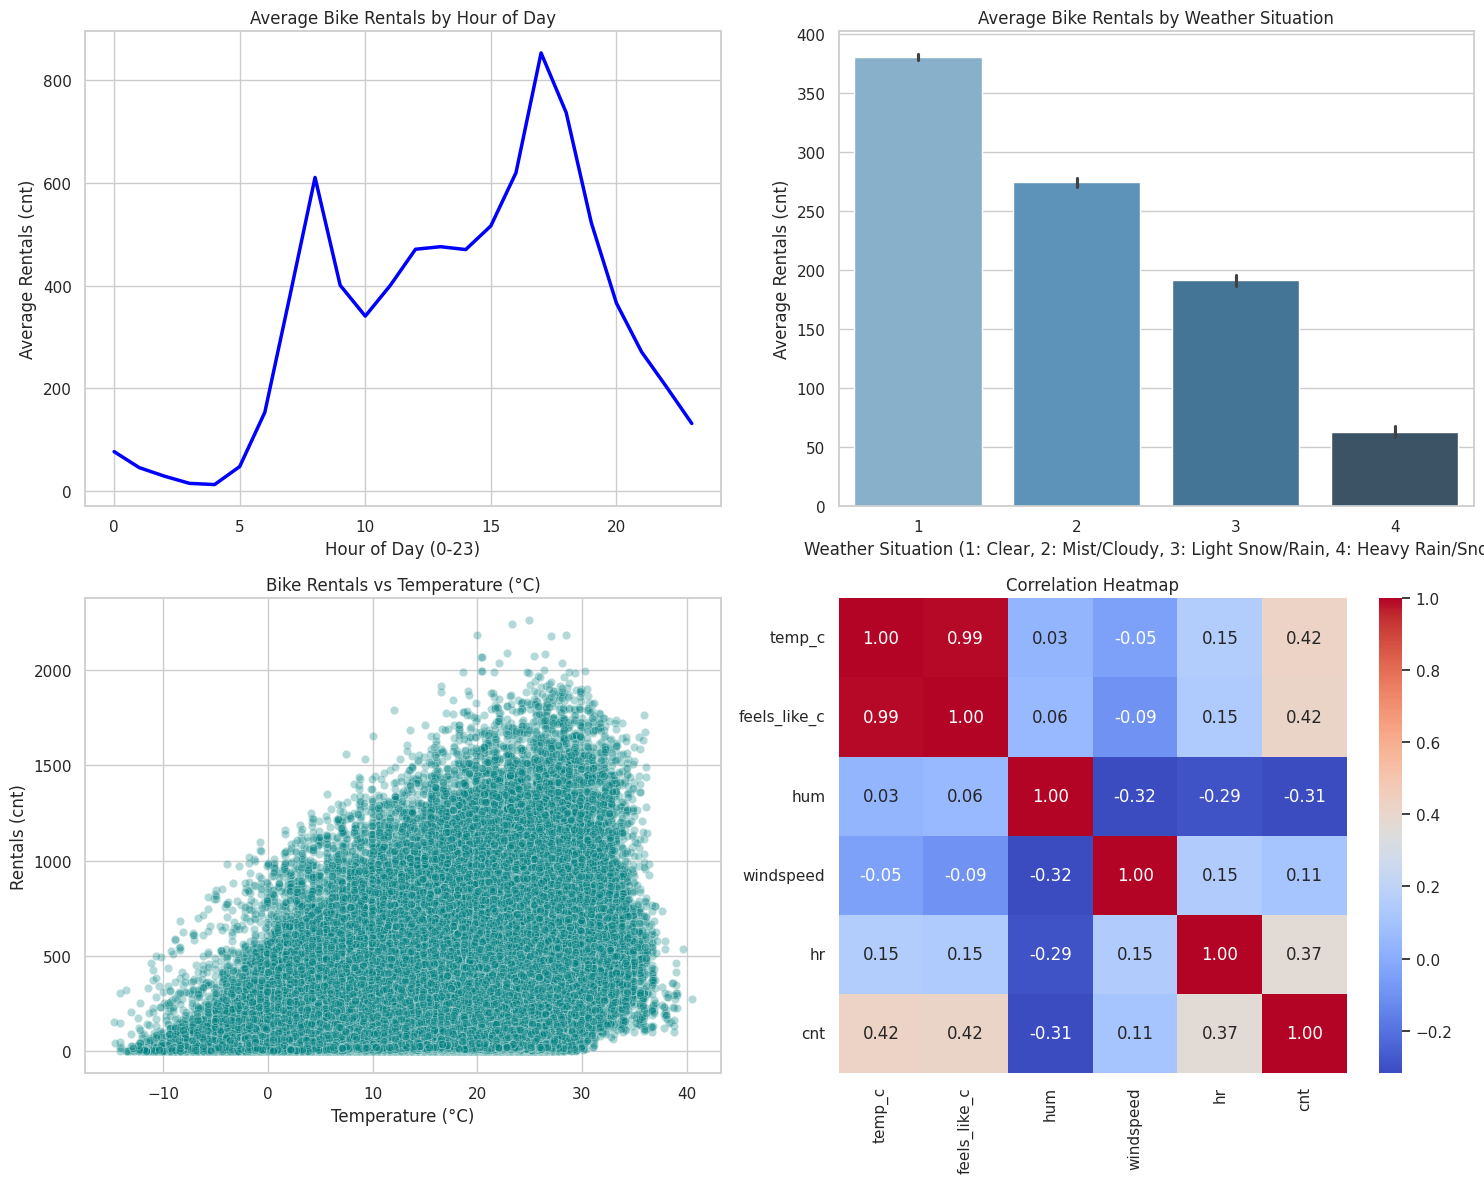

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

if 'cnt' not in df.columns:
    df['cnt'] = df['casual'] + df['registered']

sns.set_theme(style="whitegrid")
plt.figure(figsize=(15, 12))

plt.subplot(2, 2, 1)
sns.lineplot(data=df, x='hr', y='cnt', estimator='mean', errorbar=None, color='blue', linewidth=2.5)
plt.title('Average Bike Rentals by Hour of Day')
plt.xlabel('Hour of Day (0-23)')
plt.ylabel('Average Rentals (cnt)')

plt.subplot(2, 2, 2)
sns.barplot(data=df, x='weathersit', y='cnt', palette='Blues_d')
plt.title('Average Bike Rentals by Weather Situation')
plt.xlabel('Weather Situation (1: Clear, 2: Mist/Cloudy, 3: Light Snow/Rain, 4: Heavy Rain/Snow)')
plt.ylabel('Average Rentals (cnt)')

plt.subplot(2, 2, 3)
sns.scatterplot(data=df, x='temp_c', y='cnt', alpha=0.3, color='teal')
plt.title('Bike Rentals vs Temperature (°C)')
plt.xlabel('Temperature (°C)')
plt.ylabel('Rentals (cnt)')

plt.subplot(2, 2, 4)
num_cols = ['temp_c', 'feels_like_c', 'hum', 'windspeed', 'hr', 'cnt']
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')

plt.tight_layout()
plt.show()

In [5]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X = df.drop(columns=['cnt', 'casual', 'registered', 'dteday'], errors='ignore')
y = df['cnt']

print("Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

model = LinearRegression()
model.fit(X_train, y_train)
print("\nLinear Regression Model successfully trained!")

y_pred = model.predict(X_test)

results_df = pd.DataFrame({
    'Actual Rentals (y_test)': y_test.values[:10],
    'Predicted Rentals (y_pred)': np.round(y_pred[:10], 2),
    'Difference': np.round(np.abs(y_test.values[:10] - y_pred[:10]), 2)
})

print("\n--- Sample Predictions (First 10 Rows) ---")
display(results_df)

Features (X) shape: (112475, 13)
Target (y) shape: (112475,)
Training set size: 89980 samples
Testing set size: 22495 samples

Linear Regression Model successfully trained!

--- Sample Predictions (First 10 Rows) ---


,Actual Rentals (y_test),Predicted Rentals (y_pred),Difference
0,618,590.94,27.06
1,1157,460.94,696.06
2,391,556.72,165.72
3,673,528.83,144.17
4,30,23.47,6.53
5,378,364.44,13.56
6,722,392.87,329.13
7,1257,580.94,676.06
8,74,430.53,356.53
9,67,150.01,83.01


--- Model Evaluation Metrics ---
Mean Absolute Error (MAE): 199.8958
Mean Squared Error (MSE): 73277.9389
Root Mean Squared Error (RMSE): 270.6990
R² Score: 0.3767


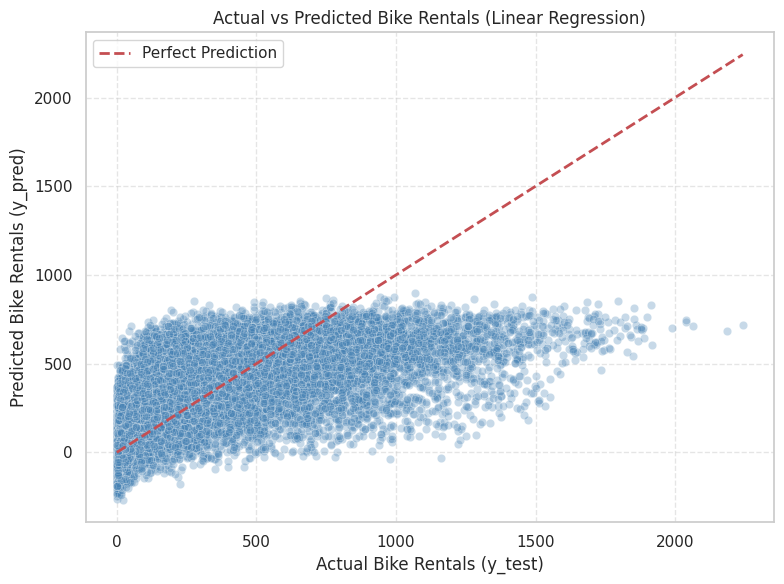

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("--- Model Evaluation Metrics ---")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R² Score: {r2:.4f}")

plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.3, color='steelblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')

plt.xlabel('Actual Bike Rentals (y_test)')
plt.ylabel('Predicted Bike Rentals (y_pred)')
plt.title('Actual vs Predicted Bike Rentals (Linear Regression)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [8]:
import ipywidgets as widgets
from IPython.display import display, HTML
import pandas as pd
import numpy as np

season_widget = widgets.Dropdown(options=[(1, 1), (2, 2), (3, 3), (4, 4)], value=1, description='Season:')
yr_widget = widgets.Dropdown(options=[('2011 (0)', 0), ('2012 (1)', 1)], value=1, description='Year:')
mnth_widget = widgets.IntSlider(min=1, max=12, value=6, description='Month:')
hr_widget = widgets.IntSlider(min=0, max=23, value=17, description='Hour:')
holiday_widget = widgets.Dropdown(options=[('No', 0), ('Yes', 1)], value=0, description='Holiday:')
weekday_widget = widgets.IntSlider(min=0, max=6, value=3, description='Weekday:')
workingday_widget = widgets.Dropdown(options=[('No', 0), ('Yes', 1)], value=1, description='Working Day:')
weathersit_widget = widgets.Dropdown(
    options=[('Clear/Few Clouds (1)', 1), ('Mist/Cloudy (2)', 2), ('Light Snow/Rain (3)', 3), ('Heavy Rain/Snow (4)', 4)],
    value=1,
    description='Weather:'
)
temp_widget = widgets.FloatSlider(min=0.0, max=1.0, step=0.02, value=0.60, description='Temp (norm):')
atemp_widget = widgets.FloatSlider(min=0.0, max=1.0, step=0.02, value=0.58, description='A-Temp:')
hum_widget = widgets.FloatSlider(min=0.0, max=1.0, step=0.02, value=0.50, description='Humidity:')
windspeed_widget = widgets.FloatSlider(min=0.0, max=1.0, step=0.02, value=0.20, description='Windspeed:')

output_area = widgets.Output()

def predict_demand(b):

    user_inputs = {
        'season': season_widget.value,
        'yr': yr_widget.value,
        'mnth': mnth_widget.value,
        'hr': hr_widget.value,
        'holiday': holiday_widget.value,
        'weekday': weekday_widget.value,
        'workingday': workingday_widget.value,
        'weathersit': weathersit_widget.value,
        'temp': temp_widget.value,
        'atemp': atemp_widget.value,
        'hum': hum_widget.value,
        'windspeed': windspeed_widget.value
    }

    input_row = {}
    for col in X.columns:
        if col in user_inputs:
            input_row[col] = user_inputs[col]
        elif col in df.columns:

            input_row[col] = df[col].mean()
        else:
            input_row[col] = 0

    input_df = pd.DataFrame([input_row])[X.columns]

    predicted_val = model.predict(input_df)[0]
    final_pred = max(0, int(np.round(predicted_val)))

    with output_area:
        output_area.clear_output()
        display(HTML(f"""
        <div style="background-color: #1e1e2e; color: #a6e3a1; padding: 15px; border-radius: 8px; font-family: monospace; font-size: 16px;">
            ⚽ <b>Predicted Bike Demand:</b> <span style="font-size: 24px; color: #f9e2af;">{final_pred} rentals/hour</span>
        </div>
        """))

predict_btn = widgets.Button(
    description='Predict Bike Demand',
    button_style='success',
    icon='calculator',
    layout=widgets.Layout(width='250px', height='40px')
)
predict_btn.on_click(predict_demand)

print("==================================================")
print("     BIKE RENTAL DEMAND PREDICTION APPLICATION     ")
print("==================================================")

left_box = widgets.VBox([season_widget, yr_widget, mnth_widget, hr_widget, holiday_widget, weekday_widget])
right_box = widgets.VBox([workingday_widget, weathersit_widget, temp_widget, atemp_widget, hum_widget, windspeed_widget])
input_ui = widgets.HBox([left_box, right_box])

display(input_ui)
display(predict_btn)
display(output_area)

     BIKE RENTAL DEMAND PREDICTION APPLICATION     


Button(button_style='success', description='Predict Bike Demand', icon='calculator', layout=Layout(height='40p…

Output()